In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')
sys.path.insert(1, 'D:\\Programi\\pyFBS\\')

In [2]:
import pyFBS #v __init.py__ bi morale knjižnice IO, SEMM in VPT pisati z malo: io, semm, vpt?
from pyEMA import pyEMA
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from time import time,sleep
from pyFBS.utility import *

## Example of modal analysis on a simple beam

#### 3D View
Open 3Dviewer in the background, with CSYS in origin

In [3]:
view3D = pyFBS.display.view3D()

Add a structure from .stl file to the 3D 

In [4]:
AB_stl = "../data/LADISK_laser/STL/T_structure.stl"
view3D.add_stl(AB_stl,color = "#8FB1CC")

#### Accelerometers
Add accelerometers from .xlsx file together with appropriate labels

In [5]:
AB = "../data/LADISK_laser/Measurements/Excel/T_structure.xlsx"
df = pd.read_excel(AB, sheet_name='Sensors_A')
view3D.show_acc(df)
df
#view3D.label_acc(df)

,Name,Description,Type,Size,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Orientation_1,Orientation_2,Orientation_3
0,Sensor 1,T_test,Mic,0.01,1,100,Acceleration,m/s^2,0.0075,0.0075,0,0,0,0
1,Sensor 2,T_test,Mic,0.01,2,100,Acceleration,m/s^2,0.0200,0.0075,0,0,0,0
2,Sensor 3,T_test,Mic,0.01,3,100,Acceleration,m/s^2,0.0325,0.0075,0,0,0,0
3,Sensor 4,T_test,Mic,0.01,4,100,Acceleration,m/s^2,0.0450,0.0075,0,0,0,0
4,Sensor 5,T_test,Mic,0.01,5,100,Acceleration,m/s^2,0.0575,0.0075,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,Sensor 59,T_test,Mic,0.01,59,100,Acceleration,m/s^2,0.0575,0.0825,0,0,0,0
59,Sensor 60,T_test,Mic,0.01,60,100,Acceleration,m/s^2,0.0700,0.0825,0,0,0,0
60,Sensor 61,T_test,Mic,0.01,61,100,Acceleration,m/s^2,0.0825,0.0825,0,0,0,0
61,Sensor 62,T_test,Mic,0.01,62,100,Acceleration,m/s^2,0.0950,0.0825,0,0,0,0


#### Channels
Add corresponding channels from .xlsx file together with appropriate labels

In [6]:
df = pd.read_excel(AB, sheet_name='Channels_A')

view3D.show_chn(df)
view3D.label_chn(df)

df

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
0,z,T_test,Translation,Acceleration,m/s^2,T_test,1,100,0.0075,0.0075,0,0,0,1,NaN
1,z,T_test,Translation,Acceleration,m/s^2,T_test,2,100,0.0200,0.0075,0,0,0,1,NaN
2,z,T_test,Translation,Acceleration,m/s^2,T_test,3,100,0.0325,0.0075,0,0,0,1,NaN
3,z,T_test,Translation,Acceleration,m/s^2,T_test,4,100,0.0450,0.0075,0,0,0,1,NaN
4,z,T_test,Translation,Acceleration,m/s^2,T_test,5,100,0.0575,0.0075,0,0,0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,z,T_test,Translation,Acceleration,m/s^2,T_test,59,100,0.0575,0.0825,0,0,0,1,NaN
59,z,T_test,Translation,Acceleration,m/s^2,T_test,60,100,0.0700,0.0825,0,0,0,1,NaN
60,z,T_test,Translation,Acceleration,m/s^2,T_test,61,100,0.0825,0.0825,0,0,0,1,NaN
61,z,T_test,Translation,Acceleration,m/s^2,T_test,62,100,0.0950,0.0825,0,0,0,1,NaN


#### Impacts
Add impacts from .xlsx with appropriate labels

In [7]:
df = pd.read_excel(AB, sheet_name='Impacts_A')

view3D.show_imp(df)
view3D.label_imp(df)

df

,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
0,I1,T_test,17,1,Force,N,0.095,0.02,-0.008,0,0,1


### Modal analysis
First load the data

In [26]:
freq = pd.read_csv("../data/LADISK_laser/Measurements/freq.txt", sep='	', squeeze=True, header=None).to_numpy()
Y = pd.read_csv("../data/LADISK_laser/Measurements/FRF.txt", sep='	', dtype=object, header=None,)\
            .applymap(lambda s: np.complex(s.replace('i', 'j'))).to_numpy()

In [27]:
np.shape(Y)

(63, 3200)

In [28]:
np.shape(freq)

(3200,)

Modeshape identification using pyEMA (LSCF/LSFD)

In [29]:
a = pyEMA.Model(
    Y,
    freq,
    pol_order_high=30,
    lower = 500,
    upper = 3200
    )

a.get_poles()

#fn_temp, xi_temp, test_fn, test_xi = pyEMA.stabilisation(a.all_poles, a.pol_order_high, err_fn=1, err_xi=0.5)

approx_nat_freq = [938, 1973, 2150, 2678, 2751, 3024]
a.select_closest_poles(approx_nat_freq)
#a.stab_chart()

100%|██████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 109.91it/s]


In [31]:
#tukaj preoblikujem matriko Y sicer naslednja celica ne deluje - če jo preoblikujem prej ne deluje pyEMA
Y = np.reshape(Y, (63, 1, 3200))

In [32]:
H_acc, A_acc = a.get_constants(whose_poles=a,least_squares_type="old")
_modes_acc = modeshape_scaling_DP(A_acc,0)

new_mode = unflattenFRFs(_modes_acc,Y)

In [33]:
np.shape(new_mode)

(63, 1, 6)

#### Create mesh

In [34]:
df = pd.read_excel(AB, sheet_name='Sensors_A')
pos_array = df[["Position_1","Position_2","Position_3"]].to_numpy()*1000

point_cloud = pv.PolyData(pos_array)
surf = point_cloud.delaunay_2d()
mesh_actor = view3D.plot.add_mesh(surf,scalars = np.zeros(np.shape(df[["Position_1","Position_2","Position_3"]].to_numpy())[0]),clim = [-1,1],color = "k", cmap="viridis",name = "mesh")#,show_edges=True)#,render_points_as_spheres = True,point_size=20)

pts = point_cloud.points.copy()

#### Display modeshape and add Animate button

In [35]:
df = pd.read_excel(AB, sheet_name='Sensors_A')
sen_or = df[["Orientation_1","Orientation_2","Orientation_3"]].to_numpy()[0]
R = eulerAnglesToRotationMatrix(sen_or*np.pi/180)

In [36]:
select = 1
scale = 10

mode_shape = new_mode[:,:,select]#@R 
#complex_plot_3D(mode_shape)
mode_dict = dict()

mode_dict["freq"] = a.nat_freq[select]
mode_dict["damp"] = a.nat_xi[select]*100
mode_dict["mcf"] = MCF(mode_shape.flatten())*100

mode_dict["animation_pts"] = mode_animation(mode_shape,scale,no_points = 60)
mode_dict["mesh"] = surf
mode_dict["or_pts"] = pts

mode_dict["scalars"] = True
mode_dict["fps"] = 30

view3D.add_modeshape(mode_dict,run_animation = True)

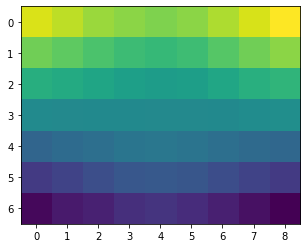

In [38]:
plt.imshow(np.reshape(np.real(mode_shape), (7, 9)));